# AT1 Example III: predicting passenger occupancy of PKP Intercity trains

**Subject:** 42172 Introduction to Artificial Intelligence, UTS

**Student:** Le Binh Nguyen (26205599)

**Problem.** A long-distance train operator wants to know, before a train departs, how full it will be. Occupancy is reported by PKP Intercity in three bands: low (under 50%), medium (50% to 80%) and high (over 80%). This notebook builds and compares classifiers that predict the band of a train run from information that is available at planning time only: the timetable, the calendar, the route, the weather forecast and planned infrastructure restrictions.

**Data.** Open dataset "PKP Intercity delays" (Kostrz, 2026), Zenodo, DOI 10.5281/zenodo.21700869, licence CC BY 4.0. It covers 1 March 2026 to 19 May 2026 and was published after the cut-off of most public tutorials, so no ready-made solution exists for this classification task.

**Techniques compared.** Random forest (Week 4.5) and a feedforward neural network (Week 5.3), against a logistic regression baseline (Week 4.6) and two naive baselines.

**Design principles carried over from the previous examples.**

1. Split chronologically before any tuning, and touch the test set once.
2. Compare against baselines that are hard to beat, not only the majority class.
3. Give every tuned model the same tuning budget.
4. Test differences with a paired significance test, not by eyeballing a single number.
5. Report stability across random seeds and the cost of each model, not only accuracy.

**Notebook map.**

1. Setup
2. Data loading and checks
3. Problem formulation: from stop records to one row per run
4. Exploratory analysis
5. Chronological split
6. Preprocessing
7. Baselines
8. Tuning random forest, FNN and logistic regression
9. Final evaluation on the test set
10. Statistical comparison
11. Stability and cost
12. What drives the predictions
13. Where the models fail
14. Summary table

## 1. Setup

### 1.1 Libraries and reproducibility

This cell imports every library used in the notebook and fixes the random seed for Python, NumPy and TensorFlow so that every seed-dependent result can be reproduced. The versions are printed so the environment is recorded alongside the results. scikit-learn provides the preprocessing, logistic regression, random forest and metrics. TensorFlow with Keras provides the feedforward network, in the same style as the Lab 3 notebooks. SciPy provides the exact binomial test used for the significance comparison.

In [1]:
import os
import sys
import glob
import json
import time
import random
import platform
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker
import joblib
import tensorflow as tf
import sklearn
import scipy
from scipy.stats import binomtest
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, cohen_kappa_score,
                             confusion_matrix, f1_score, log_loss, precision_recall_fscore_support)
from sklearn.model_selection import ParameterSampler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print('Python      :', platform.python_version())
print('NumPy       :', np.__version__)
print('pandas      :', pd.__version__)
print('scikit-learn:', sklearn.__version__)
print('SciPy       :', scipy.__version__)
print('TensorFlow  :', tf.__version__)
print('GPU devices :', tf.config.list_physical_devices('GPU'))

Python      : 3.13.15
NumPy       : 2.1.3
pandas      : 2.2.3
scikit-learn: 1.6.1
SciPy       : 1.16.3
TensorFlow  : 2.20.0
GPU devices : []


### 1.2 Experiment settings

All budget-like numbers are collected in one place so they are visible and cannot drift between sections. `N_TUNING_ITER` is the number of random configurations tried for the random forest and for the FNN. Both get the same number, which is the equal tuning budget used for the fair comparison. `N_STABILITY_SEEDS` is the number of repeated fits used to measure seed stability. `N_BOOTSTRAP` is the number of resamples used for confidence intervals. `MAX_EPOCHS` caps the FNN training length, with early stopping deciding the actual length.

In [2]:
N_TUNING_ITER = 20
N_STABILITY_SEEDS = 5
N_BOOTSTRAP = 1000
MAX_EPOCHS = 60
TRAIN_FRACTION = 0.70
VALIDATION_FRACTION = 0.15
CLASSES = [1, 2, 3]
CLASS_LABELS = ['Low (<50%)', 'Medium (50-80%)', 'High (>80%)']
print('Tuning budget per tuned model:', N_TUNING_ITER, 'configurations')

Tuning budget per tuned model: 20 configurations


### 1.3 Google Drive, folders and data location

The notebook reads the data from Google Drive and writes figures and results back to Drive, so that nothing is lost if the Colab session ends. The data file is found by searching Drive for its name rather than by hard-coding a path, so the notebook still works if the data folder is moved. The folders `figures` and `results` are created next to the notebook working folder.

In [3]:
from google.colab import drive
drive.mount('/content/gdrive')

BASE_DIR = '/content/gdrive/MyDrive/IntroToAI/AT1_III'
FIG_DIR = os.path.join(BASE_DIR, 'figures')
RES_DIR = os.path.join(BASE_DIR, 'results')
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(RES_DIR, exist_ok=True)

DATA_NAME = 'train_delays_tabular.parquet'
DATA_PATH = None
for root in ['/content/gdrive/MyDrive/IntroToAI', '/content/gdrive/MyDrive']:
    hits = glob.glob(os.path.join(root, '**', DATA_NAME), recursive=True)
    if hits:
        DATA_PATH = hits[0]
        break

assert DATA_PATH is not None, DATA_NAME + ' was not found in Google Drive'
print('Data file:', DATA_PATH)
print('Size (MB):', round(os.path.getsize(DATA_PATH) / 1e6, 1))

Mounted at /content/gdrive
Data file: /content/gdrive/MyDrive/IntroToAI/AT1_III/data/train_delays_tabular.parquet
Size (MB): 13.8


### 1.4 Plot style

One shared style cell is used for all figures so they look consistent. The three colours are a colour-vision-deficiency-safe palette. Every series is also labelled directly on the plot, so no figure depends on colour alone. Each figure is saved at 200 dpi to Drive and also shown inline, so it survives in the printed notebook.

In [4]:
BLUE, ORANGE, GREEN, GREY = '#2a78d6', '#eb6834', '#1baf7a', '#6b7280'
CLASS_COLORS = [BLUE, GREEN, ORANGE]
MODEL_COLORS = {'Random forest': BLUE, 'FNN': ORANGE, 'Logistic regression': GREEN}

plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'legend.frameon': False,
})

def save_fig(fig, name):
    fig.savefig(os.path.join(FIG_DIR, name + '.png'), dpi=200, bbox_inches='tight')
    plt.show()

## 2. Data loading and checks

### 2.1 Load the processed table

The dataset authors provide a processed table with one row per train stop (558,334 rows, 57 columns). It is loaded and sorted by run and stop order. Note that this is a stop-level table: the same train run appears once for every stop it makes.

In [5]:
stops = pd.read_parquet(DATA_PATH)
stops = stops.sort_values(['run_id', 'stop_order']).reset_index(drop=True)
print('Rows   :', len(stops))
print('Columns:', stops.shape[1])
print('Train runs:', stops['run_id'].nunique())
stops.head()

Rows   : 558334
Columns: 57
Train runs: 33378


,delta_delay,difficulty_id,prev_delay_departure_min,is_prev_departure_delay_imputed,run_id,station_id,stop_order,segment_id,service_id,category_code,distance_from_start_km,is_international,min_technical_time_min,time_reserve_min,occupancy_id,occupancy_level,day_of_week,day_category,arrival_hour_sin,arrival_hour_cos,departure_hour_sin,departure_hour_cos,month_sin,month_cos,edge_active_difficulty_id,edge_active_difficulty_p90,is_track_closure,track_closure_length,is_speed_warning,speed_warning_length,station_scheduled_dwell_time_P50,station_scheduled_dwell_time_MAD,station_scheduled_dwell_time_P90,station_delta_stop_min_P50,station_delta_stop_min_MAD,station_delta_stop_min_P90,edge_delta_edge_min_P50,edge_delta_edge_min_MAD,edge_delta_edge_min_P90,edge_delta_delay_P50,edge_delta_delay_P90,edge_delta_delay_MAD,temperature_2m,snowfall,snow_depth,is_freezing_threshold,is_heavy_precipitation,is_frost_and_precip,is_rain_with_snowcover,passenger_volume_rank,num_platforms,num_platform_tracks,intersecting_lines_count,is_node,is_passing_loop,node_historical_hazard_intensity,edge_historical_hazard_intensity
0,0.0,0,0.0,0,64189,484,2,482_484,465,IC,5.200000,0,4.0,1.0,4,1,6,Inny,0.91176,0.41072,0.92220,0.38671,1.0,0.0,0,0.0,0,0.0,0,0.000,2.0,3.85678,5.8,0.0,2.45058,0.0,0.0,0.36944,0.0,0.0,0.0000,0.0,4.0,0.0,0.0,0,0,0,0,27.0,3,6,5,1,1,0.11368,0.06641
1,0.0,0,0.0,0,64189,485,3,484_485,465,IC,26.100000,0,10.0,3.0,4,1,6,Inny,0.94264,0.33381,0.94552,0.32557,1.0,0.0,0,0.0,0,0.0,0,0.000,1.0,0.29285,1.1,0.0,3.33147,0.0,0.0,1.84493,4.0,0.0,2.9101,0.0,3.6,0.0,0.0,0,0,0,0,58.0,3,6,6,1,1,0.08741,0.05562
2,0.0,0,0.0,0,64189,486,4,485_486,465,IC,65.400002,0,17.0,1.0,4,1,6,Inny,0.96815,0.25038,0.97030,0.24192,1.0,0.0,0,0.0,0,0.0,1,0.963,1.0,0.30337,2.0,0.0,0.34225,0.0,0.0,1.16063,3.1,0.0,3.0000,0.0,4.0,0.0,0.0,0,0,0,0,18.0,3,4,6,1,1,0.10607,0.16746
3,0.0,0,0.0,0,64189,487,5,486_487,465,IC,88.199997,0,9.0,2.0,4,1,6,Inny,0.98079,0.19509,0.98163,0.19081,1.0,0.0,0,0.0,0,0.0,1,4.722,1.0,0.32662,2.0,0.0,0.51185,0.0,0.0,0.44811,1.1,0.0,1.0000,0.0,3.8,0.0,0.0,0,0,0,0,20.0,2,3,1,0,0,0.08252,0.15856
4,0.0,0,0.0,0,64189,488,6,487_488,465,IC,128.199997,0,17.0,2.0,4,1,6,Inny,0.99406,0.10887,0.99452,0.10453,1.0,0.0,0,0.0,0,0.0,1,9.172,1.0,0.49259,2.0,0.0,0.56247,1.0,0.0,3.03038,4.5,NaN,NaN,NaN,4.2,0.0,0.0,0,0,0,0,11.0,7,14,18,1,1,0.10814,NaN


### 2.2 Check the unit of the label

The label `occupancy_level` is reported by the operator for a whole train run. If it is constant within each run, then the real number of independent examples is the number of runs, not the number of stop rows, and a random row-level split would put stops of the same run into both training and test sets and inflate every score. This cell checks that property explicitly and stops the notebook if it does not hold.

In [6]:
values_per_run = stops.groupby('run_id')['occupancy_level'].nunique()
print('Runs with more than one occupancy value:', int((values_per_run > 1).sum()))
assert (values_per_run == 1).all()
print('Rows per run: min', stops.groupby('run_id').size().min(),
      '| median', int(stops.groupby('run_id').size().median()),
      '| max', stops.groupby('run_id').size().max())
print('Effective sample size is the number of runs:', stops['run_id'].nunique(),
      'not the number of rows:', len(stops))

Runs with more than one occupancy value: 0
Rows per run: min 1 | median 16 | max 44
Effective sample size is the number of runs: 33378 not the number of rows: 558334


### 2.3 Missing values

This cell lists the columns that contain missing values, with their share. Missing values are imputed later, inside the preprocessing pipeline and using the training set only, so that no information from the validation or test runs leaks into the imputation.

In [7]:
missing = stops.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]
pd.DataFrame({'missing_share': missing.round(4)})

,missing_share
edge_delta_delay_P90,0.1562
edge_delta_delay_MAD,0.1562
edge_historical_hazard_intensity,0.1562
edge_delta_delay_P50,0.1562
station_scheduled_dwell_time_P50,0.0970
station_scheduled_dwell_time_P90,0.0970
station_scheduled_dwell_time_MAD,0.0970
station_delta_stop_min_P50,0.0554
station_delta_stop_min_MAD,0.0554
station_delta_stop_min_P90,0.0554


## 3. Problem formulation: from stop records to one row per run

### 3.1 What is predicted, and when

The target is the occupancy band of a train run: 1 = low, 2 = medium, 3 = high. The prediction is made at **planning time**, before the train departs. This is a deliberate design choice: a model is only useful for planning if it does not need information that arrives later. It also removes the main leakage risks in this dataset.

The columns below are therefore excluded from the features, with the reason for each.

In [8]:
excluded = pd.DataFrame([
    ('occupancy_level, occupancy_id', 'The label itself and its identifier'),
    ('delta_delay, prev_delay_departure_min, is_prev_departure_delay_imputed', 'Delay values are only known after or during the run'),
    ('difficulty_id', 'Disruption logged during the run; the dataset authors warn about target leakage'),
    ('edge_active_difficulty_id, edge_active_difficulty_p90', 'Live disruptions on the segment, not known at planning time'),
    ('station and edge rolling delay statistics (P50, P90, MAD)', 'Built from delay history; excluded to keep planning-time information only and to avoid any hidden overlap with the test period'),
    ('service_id, station_id, segment_id, run_id, stop_order', 'Identifiers, not meaningful numeric features'),
], columns=['excluded columns', 'reason'])
excluded

,excluded columns,reason
0,"occupancy_level, occupancy_id",The label itself and its identifier
1,"delta_delay, prev_delay_departure_min, is_prev...",Delay values are only known after or during th...
2,difficulty_id,Disruption logged during the run; the dataset ...
3,"edge_active_difficulty_id, edge_active_difficu...","Live disruptions on the segment, not known at ..."
4,station and edge rolling delay statistics (P50...,Built from delay history; excluded to keep pla...
5,"service_id, station_id, segment_id, run_id, st...","Identifiers, not meaningful numeric features"


### 3.2 Aggregate stops into one row per run

Because the label belongs to the run, each run is turned into one row. Route-level quantities are aggregated over its stops: distance, number of stops, timetable buffers, mean station size, the share of stops under a track closure or a temporary speed restriction, and mean weather. Calendar features (day of week, calendar day category and month) are constant within a run.

The dataset starts each run at its second stop, so "first stop" and "last stop" below mean the first and last recorded stop after the origin. Hours are recovered from the sine and cosine encoding supplied by the authors. Weather values are treated as forecasts that would be available at planning time, which is an assumption stated here and again in the report.

In [9]:
def hour_from_cyclic(sin_values, cos_values):
    return (np.degrees(np.arctan2(sin_values, cos_values)) % 360) / 15


def build_run_table(stop_table):
    grouped = stop_table.groupby('run_id', sort=True)
    first = grouped.first()
    last = grouped.last()
    runs = pd.DataFrame(index=first.index)
    runs['service_id'] = first['service_id']
    runs['occupancy'] = first['occupancy_level'].astype(int)
    runs['category'] = first['category_code'].astype(str)
    runs['is_international'] = first['is_international'].astype(int)
    runs['day_of_week'] = first['day_of_week'].astype(int).astype(str)
    runs['day_category'] = first['day_category'].astype(str)
    runs['month_sin'] = first['month_sin']
    runs['month_cos'] = first['month_cos']
    runs['first_stop_hour'] = hour_from_cyclic(first['arrival_hour_sin'], first['arrival_hour_cos'])
    runs['last_stop_hour'] = hour_from_cyclic(last['arrival_hour_sin'], last['arrival_hour_cos'])
    runs['n_stops'] = grouped.size()
    runs['distance_km'] = grouped['distance_from_start_km'].max()
    runs['time_reserve_min'] = grouped['time_reserve_min'].sum(min_count=1)
    runs['technical_time_min'] = grouped['min_technical_time_min'].sum(min_count=1)
    runs['mean_volume_rank'] = grouped['passenger_volume_rank'].mean()
    runs['first_stop_volume_rank'] = first['passenger_volume_rank']
    runs['last_stop_volume_rank'] = last['passenger_volume_rank']
    runs['node_share'] = grouped['is_node'].mean()
    runs['temperature_mean'] = grouped['temperature_2m'].mean()
    runs['heavy_precip_share'] = grouped['is_heavy_precipitation'].mean()
    runs['snowfall_mean'] = grouped['snowfall'].mean()
    runs['closure_share'] = grouped['is_track_closure'].mean()
    runs['speed_warning_share'] = grouped['is_speed_warning'].mean()
    return runs.reset_index()


runs = build_run_table(stops)
assert runs['run_id'].is_unique
assert len(runs) == stops['run_id'].nunique()
print('Run table shape:', runs.shape)
runs.head()

Run table shape: (33378, 24)


,run_id,service_id,occupancy,category,is_international,day_of_week,day_category,month_sin,month_cos,first_stop_hour,last_stop_hour,n_stops,distance_km,time_reserve_min,technical_time_min,mean_volume_rank,first_stop_volume_rank,last_stop_volume_rank,node_share,temperature_mean,heavy_precip_share,snowfall_mean,closure_share,speed_warning_share
0,64189,465,1,IC,0,6,Inny,1.0,0.0,4.383326,7.799992,16,315.899994,23.0,146.0,96.687500,27.0,36.0,0.562500,2.443750,0.0,0.0,0.187500,0.562500
1,64190,936,1,IC,0,6,Inny,1.0,0.0,7.049993,8.449994,3,184.600006,6.0,81.0,119.666664,9.0,36.0,1.000000,2.000000,0.0,0.0,0.666667,0.666667
2,64191,344,1,TLK,0,6,Inny,1.0,0.0,10.799993,13.566670,12,284.200012,26.0,150.0,241.333328,28.0,36.0,0.500000,8.474999,0.0,0.0,0.083333,0.416667
3,64192,7,1,IC,0,6,Inny,1.0,0.0,19.999992,22.833321,12,284.200012,26.0,150.0,241.333328,28.0,36.0,0.500000,4.616666,0.0,0.0,0.083333,0.416667
4,64193,615,1,IC,0,6,Inny,1.0,0.0,6.999999,9.316671,11,212.399994,24.0,94.0,131.181824,4.0,199.0,0.454545,2.754545,0.0,0.0,0.636364,0.363636


### 3.3 Feature groups

Features are organised in six groups. The groups are used later for the ablation study, which removes one group at a time to see how much each kind of information contributes. Numeric features are imputed and scaled; categorical features are one-hot encoded.

In [10]:
GROUPS = {
    'calendar': {'num': ['month_sin', 'month_cos'], 'cat': ['day_of_week', 'day_category']},
    'timetable': {'num': ['first_stop_hour', 'last_stop_hour', 'n_stops', 'distance_km',
                          'time_reserve_min', 'technical_time_min'], 'cat': []},
    'service': {'num': ['is_international'], 'cat': ['category']},
    'network': {'num': ['mean_volume_rank', 'first_stop_volume_rank',
                        'last_stop_volume_rank', 'node_share'], 'cat': []},
    'weather': {'num': ['temperature_mean', 'heavy_precip_share', 'snowfall_mean'], 'cat': []},
    'infrastructure': {'num': ['closure_share', 'speed_warning_share'], 'cat': []},
}
NUM_COLS = [c for g in GROUPS.values() for c in g['num']]
CAT_COLS = [c for g in GROUPS.values() for c in g['cat']]
FEATURES = NUM_COLS + CAT_COLS
print('Numeric features    :', len(NUM_COLS))
print('Categorical features:', len(CAT_COLS))
print('Missing values in run table:')
print(runs[FEATURES].isna().sum()[runs[FEATURES].isna().sum() > 0])

Numeric features    : 18
Categorical features: 3
Missing values in run table:
Series([], dtype: int64)


## 4. Exploratory analysis

### 4.1 Class balance and how occupancy depends on train category

Figure 1 shows how many runs fall in each occupancy band and how the bands differ across the four commercial train categories. This tells us whether accuracy alone would be misleading (the classes are not perfectly balanced, so macro-averaged F1 is reported next to accuracy) and whether simple descriptors such as category already carry signal.

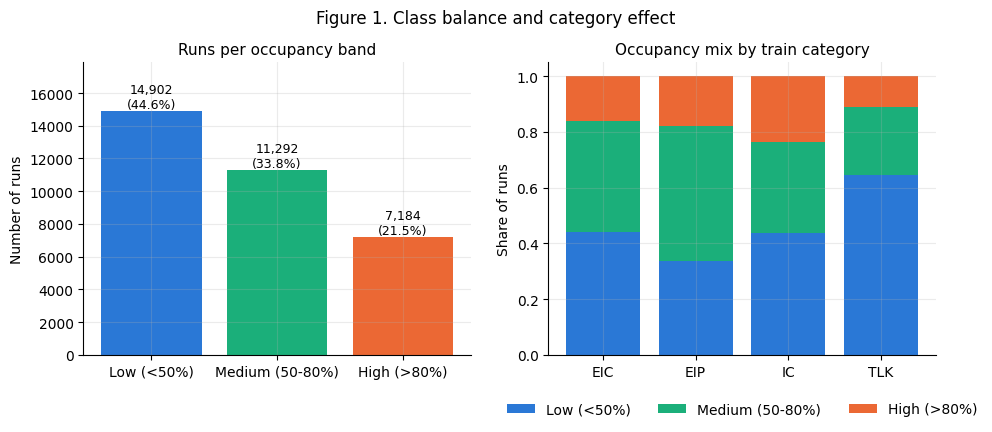

In [11]:
counts = runs['occupancy'].value_counts().sort_index()
share_by_cat = pd.crosstab(runs['category'], runs['occupancy'], normalize='index')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].bar(CLASS_LABELS, counts.values, color=CLASS_COLORS)
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f'{v:,}\n({v / counts.sum():.1%})', ha='center', va='bottom', fontsize=9)
axes[0].set_title('Runs per occupancy band')
axes[0].set_ylabel('Number of runs')
axes[0].set_ylim(0, counts.max() * 1.2)

bottom = np.zeros(len(share_by_cat))
for cls, label, colour in zip(CLASSES, CLASS_LABELS, CLASS_COLORS):
    axes[1].bar(share_by_cat.index, share_by_cat[cls], bottom=bottom, color=colour, label=label)
    bottom += share_by_cat[cls].values
axes[1].set_title('Occupancy mix by train category')
axes[1].set_ylabel('Share of runs')
axes[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3)
fig.suptitle('Figure 1. Class balance and category effect', y=1.02, fontsize=12)
save_fig(fig, 'fig1_class_balance')

### 4.2 Occupancy by time of day and day of week

Figure 2 shows the share of high-occupancy runs by the hour of the first recorded stop and by day of week. If occupancy follows daily and weekly rhythms, calendar and timetable features should help, and a model that can capture non-linear patterns should have an advantage over a linear one.

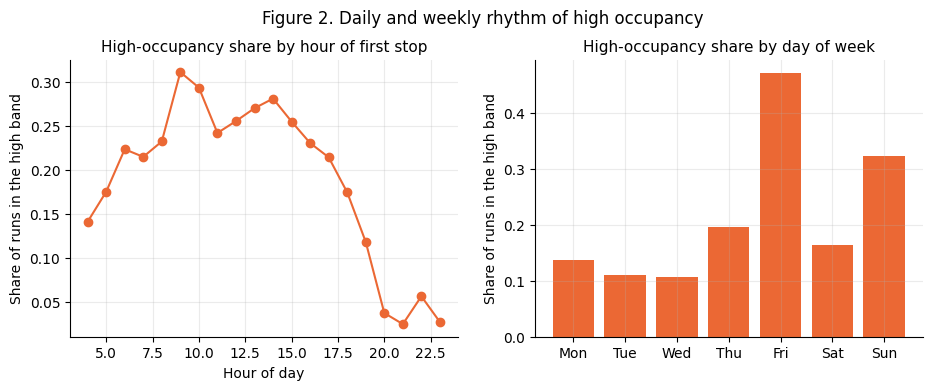

In [12]:
runs['high'] = (runs['occupancy'] == 3).astype(int)
runs['hour_bin'] = runs['first_stop_hour'].round().astype(int) % 24
by_hour = runs.groupby('hour_bin')['high'].agg(['mean', 'size'])
by_hour = by_hour[by_hour['size'] >= 100]
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
by_day = runs.groupby(runs['day_of_week'].astype(int))['high'].mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(by_hour.index, by_hour['mean'], marker='o', color=ORANGE)
axes[0].set_title('High-occupancy share by hour of first stop')
axes[0].set_xlabel('Hour of day')
axes[0].set_ylabel('Share of runs in the high band')
axes[1].bar(day_names, by_day.values, color=ORANGE)
axes[1].set_title('High-occupancy share by day of week')
axes[1].set_ylabel('Share of runs in the high band')
fig.suptitle('Figure 2. Daily and weekly rhythm of high occupancy', y=1.02, fontsize=12)
save_fig(fig, 'fig2_time_patterns')
runs = runs.drop(columns=['high', 'hour_bin'])

### 4.3 Season coverage: a limit of this dataset

The data covers only spring, so the weather features have a narrow range and winter conditions are absent. This cell quantifies that limit. It is reported as a limitation in the report, because a model trained here cannot be expected to generalise to winter timetables or holiday peaks outside this window.

In [13]:
coverage = pd.Series({
    'minimum mean temperature on a run (C)': runs['temperature_mean'].min(),
    'maximum mean temperature on a run (C)': runs['temperature_mean'].max(),
    'share of runs with any snowfall': (runs['snowfall_mean'] > 0).mean(),
    'share of runs with heavy precipitation at some stop': (runs['heavy_precip_share'] > 0).mean(),
    'distinct months in the data': runs[['month_sin', 'month_cos']].round(3).drop_duplicates().shape[0],
})
coverage.round(3).to_frame('value')

,value
minimum mean temperature on a run (C),-2.609
maximum mean temperature on a run (C),28.367
share of runs with any snowfall,0.023
share of runs with heavy precipitation at some stop,0.199
distinct months in the data,3.000


**Reading the output.** Mean run temperature ranges from -2.6 C to 28.4 C, only 2.3% of runs see any snowfall and the data covers three calendar months. The window is spring, so winter operation, Christmas peaks and summer holiday peaks are not represented. Any conclusion below holds for this window only.

## 5. Chronological split

### 5.1 Train, validation and test by run order

Runs are ordered by `run_id`, which increases with time. The first 70% of runs form the training set, the next 15% the validation set used to choose settings, and the last 15% the test set, which is used once at the end. A chronological split mimics real use: the model is trained on the past and judged on the future. The assertions confirm that the three periods do not overlap.

In [14]:
n_runs = len(runs)
i_train = int(n_runs * TRAIN_FRACTION)
i_val = int(n_runs * (TRAIN_FRACTION + VALIDATION_FRACTION))

train = runs.iloc[:i_train].reset_index(drop=True)
val = runs.iloc[i_train:i_val].reset_index(drop=True)
test = runs.iloc[i_val:].reset_index(drop=True)

assert train['run_id'].max() < val['run_id'].min()
assert val['run_id'].max() < test['run_id'].min()
assert len(train) + len(val) + len(test) == n_runs

split_table = pd.DataFrame({
    'runs': [len(train), len(val), len(test)],
    'first run_id': [train['run_id'].min(), val['run_id'].min(), test['run_id'].min()],
    'last run_id': [train['run_id'].max(), val['run_id'].max(), test['run_id'].max()],
}, index=['train', 'validation', 'test'])
split_table

,runs,first run_id,last run_id
train,23364,64189,92239
validation,5007,92240,97854
test,5007,97855,103337


### 5.2 Class shift across the split

Figure 3 shows the class mix in each period. If the mix changes over time, a model that learned the training mix will be under pressure on the test set. A visible shift here means the test score measures robustness to change, not only fit.

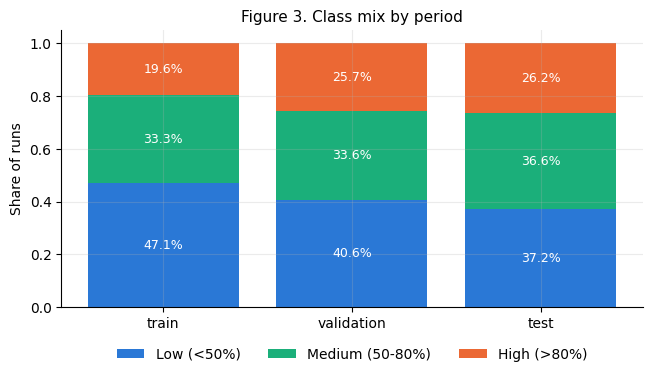

occupancy,1,2,3
train,0.471,0.333,0.196
validation,0.406,0.336,0.257
test,0.372,0.366,0.262


In [15]:
shares = pd.DataFrame({
    name: part['occupancy'].value_counts(normalize=True).sort_index()
    for name, part in [('train', train), ('validation', val), ('test', test)]
}).T

fig, ax = plt.subplots(figsize=(7.5, 3.6))
bottom = np.zeros(len(shares))
for cls, label, colour in zip(CLASSES, CLASS_LABELS, CLASS_COLORS):
    ax.bar(shares.index, shares[cls], bottom=bottom, color=colour, label=label)
    for i, v in enumerate(shares[cls].values):
        ax.text(i, bottom[i] + v / 2, f'{v:.1%}', ha='center', va='center', color='white', fontsize=9)
    bottom += shares[cls].values
ax.set_ylabel('Share of runs')
ax.set_title('Figure 3. Class mix by period')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)
save_fig(fig, 'fig3_class_shift')
shares.round(3)

**Reading the output.** The class mix moves over time. High-occupancy runs rise from 19.6% in training to 25.7% in validation and 26.2% in test, while low-occupancy runs fall from 47.1% to 37.2%. A model that learned the training mix will tend to under-predict the high band on later data. This shift is a real feature of forecasting in time and is used later to interpret the per-class results.

## 6. Preprocessing

### 6.1 One preprocessing recipe for every model

Numeric features are imputed with the training median and standardised; categorical features are one-hot encoded, with unseen categories ignored. The recipe is fitted on the training set only and then applied unchanged to validation and test. Scaling does not matter for the random forest but is needed for logistic regression and the FNN, so one shared recipe is used for all three models, which keeps the comparison fair. The one-hot output is dense because Keras needs a dense array.

In [16]:
def make_preprocessor(num_cols, cat_cols):
    transformers = []
    if num_cols:
        transformers.append(('num', Pipeline([('impute', SimpleImputer(strategy='median')),
                                              ('scale', StandardScaler())]), num_cols))
    if cat_cols:
        transformers.append(('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols))
    return ColumnTransformer(transformers)


preprocessor = make_preprocessor(NUM_COLS, CAT_COLS)
X_train = preprocessor.fit_transform(train[FEATURES])
X_val = preprocessor.transform(val[FEATURES])
X_test = preprocessor.transform(test[FEATURES])
y_train = train['occupancy'].values
y_val = val['occupancy'].values
y_test = test['occupancy'].values

print('Design matrix shapes  train / validation / test:', X_train.shape, X_val.shape, X_test.shape)
print('Any NaN left after preprocessing:', bool(np.isnan(X_train).any() or np.isnan(X_val).any() or np.isnan(X_test).any()))

Design matrix shapes  train / validation / test: (23364, 32) (5007, 32) (5007, 32)
Any NaN left after preprocessing: False


### 6.2 Evaluation helpers

All models are scored with the same function. Because the three classes are ordered (low, medium, high), the metrics include more than accuracy. Macro F1 gives each class equal weight. Balanced accuracy is the mean recall per class. Quadratic weighted kappa rewards predictions that are close on the ordered scale. The "two-band error rate" is the share of runs predicted low when truly high or the reverse, which is the most costly mistake for planning. Log loss scores the predicted probabilities, and is available for models that output them.

In [17]:
def evaluate(name, y_true, y_pred, proba=None):
    row = {
        'model': name,
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro'),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'weighted_kappa': cohen_kappa_score(y_true, y_pred, weights='quadratic'),
        'two_band_error': float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred)) == 2)),
    }
    row['log_loss'] = log_loss(y_true, proba, labels=CLASSES) if proba is not None else np.nan
    return row


def holm_adjust(p_values):
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    adjusted = np.empty(len(p_values))
    running = 0.0
    for rank, idx in enumerate(order):
        running = max(running, (len(p_values) - rank) * p_values[idx])
        adjusted[idx] = min(1.0, running)
    return adjusted

## 7. Baselines

Two naive baselines set the floor. The **majority-class** baseline always predicts the most common band in the training set. The **per-service** baseline is much harder to beat: it predicts, for each train service number, the band that service most often had in the training period, and falls back to the overall majority for services not seen before. The service number is not a model feature, so this baseline measures how much of the signal is simply "this train is usually full or empty". A model that cannot beat it has learned nothing beyond memorising services. Both are scored on the validation set here; the test set is not used yet.

In [18]:
majority_class = int(pd.Series(y_train).mode()[0])
service_mode = train.groupby('service_id')['occupancy'].agg(lambda s: s.value_counts().idxmax())


def predict_majority(frame):
    return np.full(len(frame), majority_class)


def predict_per_service(frame):
    return frame['service_id'].map(service_mode).fillna(majority_class).astype(int).values


seen_val = val['service_id'].isin(service_mode.index).mean()
seen_test = test['service_id'].isin(service_mode.index).mean()
print('Majority class in training:', majority_class)
print('Share of validation runs whose service appears in training:', round(seen_val, 3))
print('Share of test runs whose service appears in training      :', round(seen_test, 3))

baseline_val = pd.DataFrame([
    evaluate('Majority class', y_val, predict_majority(val)),
    evaluate('Per-service majority', y_val, predict_per_service(val)),
]).set_index('model')
baseline_val.round(3)

Majority class in training: 1
Share of validation runs whose service appears in training: 0.998
Share of test runs whose service appears in training      : 0.999


,accuracy,macro_f1,balanced_accuracy,weighted_kappa,two_band_error,log_loss
model,,,,,,
Majority class,0.406,0.193,0.333,0.000,0.257,NaN
Per-service majority,0.573,0.520,0.530,0.418,0.086,NaN


**Reading the output.** Almost every validation and test run belongs to a service that also appears in training (99.8% and 99.9%), so the per-service baseline is applicable almost everywhere. It reaches a validation macro F1 of 0.520 against 0.193 for the majority class, which shows that a large part of the signal is simply "this service is usually full or empty". Any useful model must clearly beat 0.52.

## 8. Tuning with an equal budget

### 8.1 Protocol

Each model is tuned on the training set and judged on the validation set by macro F1. The random forest and the FNN each receive the same number of randomly sampled configurations (`N_TUNING_ITER`). Logistic regression has a single main setting, the regularisation strength `C`, so it is tuned over a small fixed grid. Tuning tables are saved to Drive under a name that records the budget and seed, so a changed setting can never silently reload an older result. The test set stays untouched.

### 8.2 Model builders

These small functions build each model from a parameter dictionary. The FNN follows the Lab 3 pattern: a Keras `Sequential` stack of `Dense` layers with ReLU, and a three-unit softmax output. Dropout and L2 regularisation are optional. Early stopping on validation loss decides the training length, and the best weights are restored.

In [19]:
def make_logreg(params, seed=SEED):
    return LogisticRegression(C=params['C'], max_iter=3000, random_state=seed)


def make_forest(params, seed=SEED):
    return RandomForestClassifier(**params, n_jobs=-1, random_state=seed)


def build_fnn(input_dim, params):
    reg = tf.keras.regularizers.l2(params['l2']) if params['l2'] > 0 else None
    model = tf.keras.Sequential()
    model.add(tf.keras.Input(shape=(input_dim,)))
    for _ in range(params['n_layers']):
        model.add(tf.keras.layers.Dense(params['units'], activation='relu', kernel_regularizer=reg))
        if params['dropout'] > 0:
            model.add(tf.keras.layers.Dropout(params['dropout']))
    model.add(tf.keras.layers.Dense(3, activation='softmax'))
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=params['lr']),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


def fit_fnn(params, X_fit, y_fit, X_stop, y_stop, seed=SEED):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)
    model = build_fnn(X_fit.shape[1], params)
    class_weight = None
    if params['class_weight'] == 'balanced':
        weights = compute_class_weight('balanced', classes=np.array(CLASSES), y=y_fit)
        class_weight = {i: w for i, w in enumerate(weights)}
    stopper = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
    history = model.fit(X_fit, y_fit - 1, validation_data=(X_stop, y_stop - 1),
                        epochs=MAX_EPOCHS, batch_size=params['batch_size'],
                        class_weight=class_weight, callbacks=[stopper], verbose=0)
    return model, len(history.history['loss'])


def fnn_proba(model, X):
    return model.predict(X, verbose=0)


def fnn_predict(model, X):
    return fnn_proba(model, X).argmax(axis=1) + 1

### 8.3 Search spaces

The random forest varies the number of trees, depth, leaf size, the number of features tried per split and class weighting. The FNN varies depth, width, dropout, L2 strength, learning rate, batch size and class weighting. The ranges are wide enough to include both small and large models, so the budget is spent on genuinely different candidates.

In [20]:
RF_SPACE = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': ['sqrt', 0.5, 0.8],
    'class_weight': [None, 'balanced'],
}
FNN_SPACE = {
    'n_layers': [1, 2, 3],
    'units': [32, 64, 128, 256],
    'dropout': [0.0, 0.1, 0.3],
    'l2': [0.0, 1e-4, 1e-3],
    'lr': [3e-4, 1e-3, 3e-3],
    'batch_size': [128, 256, 512],
    'class_weight': [None, 'balanced'],
}
LOGREG_GRID = [{'C': c} for c in [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]]
print('Random forest candidates:', N_TUNING_ITER)
print('FNN candidates          :', N_TUNING_ITER)
print('Logistic regression grid:', len(LOGREG_GRID))

Random forest candidates: 20
FNN candidates          : 20
Logistic regression grid: 8


### 8.4 Run the tuning

Each candidate is fitted on the training set and scored on the validation set. Fit time is recorded, because cost is part of the comparison later. If a tuning table with the same budget and seed already exists on Drive it is loaded instead of recomputed. Parameter dictionaries are stored as JSON text so that `None` values survive the round trip to CSV.

In [21]:
def run_tuning(label, candidates, fit_and_score):
    path = os.path.join(RES_DIR, f'tuning_{label}_n{len(candidates)}_seed{SEED}.csv')
    if os.path.exists(path):
        print(label, ': loaded cached tuning table')
        return pd.read_csv(path)
    rows = []
    for i, params in enumerate(candidates):
        start = time.time()
        extra = fit_and_score(params)
        rows.append({'config': i, 'params': json.dumps(params), 'fit_seconds': time.time() - start, **extra})
        print(label, f'{i + 1}/{len(candidates)}', f"val macro F1 = {extra['val_macro_f1']:.4f}")
    table = pd.DataFrame(rows)
    table.to_csv(path, index=False)
    return table


def score_logreg(params):
    model = make_logreg(params).fit(X_train, y_train)
    pred = model.predict(X_val)
    return {'val_macro_f1': f1_score(y_val, pred, average='macro'), 'val_accuracy': accuracy_score(y_val, pred)}


def score_forest(params):
    model = make_forest(params).fit(X_train, y_train)
    pred = model.predict(X_val)
    return {'val_macro_f1': f1_score(y_val, pred, average='macro'), 'val_accuracy': accuracy_score(y_val, pred)}


def score_fnn(params):
    model, epochs = fit_fnn(params, X_train, y_train, X_val, y_val)
    pred = fnn_predict(model, X_val)
    return {'val_macro_f1': f1_score(y_val, pred, average='macro'), 'val_accuracy': accuracy_score(y_val, pred),
            'epochs': epochs}


rf_candidates = list(ParameterSampler(RF_SPACE, n_iter=N_TUNING_ITER, random_state=SEED))
fnn_candidates = list(ParameterSampler(FNN_SPACE, n_iter=N_TUNING_ITER, random_state=SEED))

logreg_tuning = run_tuning('logreg', LOGREG_GRID, score_logreg)
rf_tuning = run_tuning('forest', rf_candidates, score_forest)
fnn_tuning = run_tuning('fnn', fnn_candidates, score_fnn)

logreg : loaded cached tuning table
forest : loaded cached tuning table
fnn : loaded cached tuning table


### 8.5 Tuning results and the chosen configurations

The best configuration of each model is the one with the highest validation macro F1. The tables show the top five of each so that the reader can see how much the choice matters. If the top configurations are close, the result is not sensitive to the exact setting; if the best is far ahead, tuning mattered.

In [22]:
def best_params(table):
    row = table.sort_values('val_macro_f1', ascending=False).iloc[0]
    return json.loads(row['params']), row


best_logreg, row_lr = best_params(logreg_tuning)
best_rf, row_rf = best_params(rf_tuning)
best_fnn, row_fnn = best_params(fnn_tuning)

for name, table in [('Logistic regression', logreg_tuning), ('Random forest', rf_tuning), ('FNN', fnn_tuning)]:
    print(name, '| top 5 by validation macro F1')
    top = table.sort_values('val_macro_f1', ascending=False).head(5).copy()
    top['params'] = top['params'].str.slice(0, 110)
    display(top[['config', 'val_macro_f1', 'val_accuracy', 'fit_seconds', 'params']].round(4))

print('Chosen logistic regression:', best_logreg)
print('Chosen random forest      :', best_rf)
print('Chosen FNN                :', best_fnn)

Logistic regression | top 5 by validation macro F1


,config,val_macro_f1,val_accuracy,fit_seconds,params
3,3,0.4599,0.4677,4.3519,"{""C"": 1}"
5,5,0.4597,0.4673,1.1073,"{""C"": 100}"
6,6,0.4597,0.4673,1.0772,"{""C"": 1000}"
7,7,0.4595,0.4671,1.1936,"{""C"": 10000}"
4,4,0.4592,0.4669,2.0445,"{""C"": 10}"


Random forest | top 5 by validation macro F1


,config,val_macro_f1,val_accuracy,fit_seconds,params
16,16,0.6245,0.6401,2.7389,"{""n_estimators"": 100, ""min_samples_leaf"": 5, ""..."
14,14,0.6201,0.6363,7.7117,"{""n_estimators"": 300, ""min_samples_leaf"": 10, ..."
12,12,0.6119,0.6237,21.9351,"{""n_estimators"": 500, ""min_samples_leaf"": 1, ""..."
11,11,0.6109,0.6239,31.2548,"{""n_estimators"": 300, ""min_samples_leaf"": 2, ""..."
19,19,0.6069,0.6139,12.4440,"{""n_estimators"": 500, ""min_samples_leaf"": 2, ""..."


FNN | top 5 by validation macro F1


,config,val_macro_f1,val_accuracy,fit_seconds,params
12,12,0.5331,0.5522,24.7962,"{""units"": 256, ""n_layers"": 3, ""lr"": 0.003, ""l2..."
6,6,0.5215,0.5390,10.4534,"{""units"": 256, ""n_layers"": 3, ""lr"": 0.001, ""l2..."
17,17,0.5154,0.5420,8.9203,"{""units"": 32, ""n_layers"": 3, ""lr"": 0.001, ""l2""..."
2,2,0.5035,0.5277,4.7816,"{""units"": 128, ""n_layers"": 1, ""lr"": 0.003, ""l2..."
1,1,0.5022,0.5153,8.6067,"{""units"": 128, ""n_layers"": 3, ""lr"": 0.003, ""l2..."


Chosen logistic regression: {'C': 1}
Chosen random forest      : {'n_estimators': 100, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 30, 'class_weight': None}
Chosen FNN                : {'units': 256, 'n_layers': 3, 'lr': 0.003, 'l2': 0.001, 'dropout': 0.1, 'class_weight': None, 'batch_size': 512}


**Reading the output.** Logistic regression is insensitive to `C`: every value from 1 to 10,000 gives a validation macro F1 of about 0.460, so the choice of `C = 1` is a near tie and does not matter. The best random forest is also the cheapest of its top five (100 trees, fitted in under three seconds), so a bigger forest did not help. The best FNN reaches only 0.533 on validation, about 0.09 below the best forest. With the same 20-configuration budget, the forest found a much better solution than the network.

### 8.6 Tuning landscape

Figure 4 sorts all tried configurations of each model by validation macro F1. A flat line means the model is insensitive to its settings; a steep drop means a poor choice would have cost accuracy. The two tuned models used the same number of trials, so the curves are directly comparable.

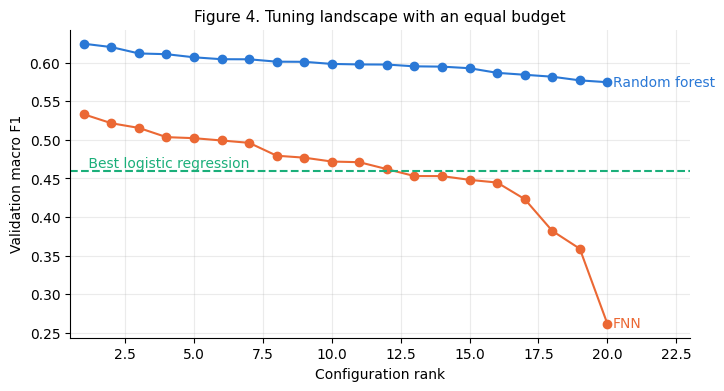

In [23]:
fig, ax = plt.subplots(figsize=(8, 4))
for name, table, colour in [('Random forest', rf_tuning, BLUE), ('FNN', fnn_tuning, ORANGE)]:
    scores = np.sort(table['val_macro_f1'].values)[::-1]
    ax.plot(range(1, len(scores) + 1), scores, marker='o', color=colour)
    ax.text(len(scores) + 0.2, scores[-1], name, color=colour, va='center')
lr_best = logreg_tuning['val_macro_f1'].max()
ax.axhline(lr_best, color=GREEN, linestyle='--')
ax.text(1, lr_best, ' Best logistic regression', color=GREEN, va='bottom')
ax.set_xlabel('Configuration rank')
ax.set_ylabel('Validation macro F1')
ax.set_title('Figure 4. Tuning landscape with an equal budget')
ax.set_xlim(0.5, N_TUNING_ITER + 3)
save_fig(fig, 'fig4_tuning_landscape')

**Reading Figure 4.** The random forest curve sits above the FNN curve at every rank, so the gap does not come from one unlucky draw. All 20 forest configurations score between about 0.575 and 0.625 on validation, a narrow band, while the FNN configurations range from about 0.53 down to 0.26, and roughly eight of them fall below the best logistic regression. The forest is easy to tune on this problem; the network is sensitive to its settings.

## 9. Final evaluation on the test set

### 9.1 Fit the chosen models and predict the test set

The three chosen configurations are fitted on the training set, with the validation set used only for early stopping of the FNN, and are then applied once to the test set. Fit time and prediction time are measured here for the main comparison. Predicted probabilities are kept so that log loss can be reported. Test predictions are also saved to Drive.

In [24]:
final = {}

start = time.time()
logreg_model = make_logreg(best_logreg).fit(X_train, y_train)
fit_time = time.time() - start
start = time.time()
proba = logreg_model.predict_proba(X_test)
predict_time = time.time() - start
final['Logistic regression'] = {'pred': proba.argmax(axis=1) + 1, 'proba': proba,
                                'fit_s': fit_time, 'predict_s': predict_time}

start = time.time()
forest_model = make_forest(best_rf).fit(X_train, y_train)
fit_time = time.time() - start
start = time.time()
proba = forest_model.predict_proba(X_test)
predict_time = time.time() - start
final['Random forest'] = {'pred': proba.argmax(axis=1) + 1, 'proba': proba,
                          'fit_s': fit_time, 'predict_s': predict_time}

start = time.time()
fnn_model, fnn_epochs = fit_fnn(best_fnn, X_train, y_train, X_val, y_val)
fit_time = time.time() - start
start = time.time()
proba = fnn_proba(fnn_model, X_test)
predict_time = time.time() - start
final['FNN'] = {'pred': proba.argmax(axis=1) + 1, 'proba': proba,
                'fit_s': fit_time, 'predict_s': predict_time}

predictions = pd.DataFrame({'run_id': test['run_id'], 'true': y_test,
                            'majority': predict_majority(test), 'per_service': predict_per_service(test),
                            **{name: v['pred'] for name, v in final.items()}})
predictions.to_csv(os.path.join(RES_DIR, f'test_predictions_seed{SEED}.csv'), index=False)
print('FNN trained for', fnn_epochs, 'epochs (early stopping)')

FNN trained for 18 epochs (early stopping)


### 9.2 Test scores

The table puts every model and both baselines on the same test runs. Read it from the bottom up: first check that the tuned models beat both baselines, especially the per-service baseline, then compare the three models with each other. The next sections test whether the gaps are larger than chance.

In [25]:
test_scores = pd.DataFrame(
    [evaluate('Majority class', y_test, predict_majority(test)),
     evaluate('Per-service majority', y_test, predict_per_service(test))] +
    [evaluate(name, y_test, v['pred'], v['proba']) for name, v in final.items()]
).set_index('model')
test_scores.to_csv(os.path.join(RES_DIR, f'test_scores_seed{SEED}.csv'))
test_scores.round(4)

,accuracy,macro_f1,balanced_accuracy,weighted_kappa,two_band_error,log_loss
model,,,,,,
Majority class,0.3719,0.1807,0.3333,0.0000,0.2624,NaN
Per-service majority,0.5998,0.5580,0.5691,0.5269,0.0529,NaN
Logistic regression,0.5552,0.5529,0.5681,0.4526,0.1017,0.9240
Random forest,0.7184,0.7090,0.7024,0.7207,0.0188,0.6673
FNN,0.5764,0.5394,0.5457,0.4386,0.0725,0.8865


**Reading the output.** The random forest reaches an accuracy of 0.718 and a macro F1 of 0.709 on the test runs. That is 15 macro F1 points above the per-service baseline (0.558) and 17 points above the FNN (0.539). The logistic regression (0.553) is on a par with the per-service baseline, so a linear model learns little beyond service identity. The FNN is below both logistic regression and the per-service baseline on macro F1, although its accuracy (0.576) is above logistic regression (0.555). The two metrics disagree because the FNN rarely predicts the high band (next table). On the ordinal metrics the forest is far ahead too: weighted kappa 0.721 against 0.439 and a two-band error of 1.9% against 7.3%.

### 9.3 Per-class results

Overall scores can hide a weak class. This cell reports precision, recall and F1 for each occupancy band and each model. Pay attention to the high band: it is the minority class and the one an operator cares most about, because it signals crowding.

In [26]:
rows = []
for name, v in final.items():
    precision, recall, f1, support = precision_recall_fscore_support(y_test, v['pred'], labels=CLASSES, zero_division=0)
    for i, label in enumerate(CLASS_LABELS):
        rows.append({'model': name, 'class': label, 'precision': precision[i], 'recall': recall[i],
                     'f1': f1[i], 'support': int(support[i])})
per_class = pd.DataFrame(rows)
per_class.round(3)

,model,class,precision,recall,f1,support
0,Logistic regression,Low (<50%),0.676,0.598,0.634,1862
1,Logistic regression,Medium (50-80%),0.541,0.412,0.467,1831
2,Logistic regression,High (>80%),0.465,0.695,0.557,1314
3,Random forest,Low (<50%),0.716,0.918,0.805,1862
4,Random forest,Medium (50-80%),0.644,0.628,0.636,1831
5,Random forest,High (>80%),0.883,0.561,0.686,1314
6,FNN,Low (<50%),0.575,0.813,0.673,1862
7,FNN,Medium (50-80%),0.518,0.560,0.538,1831
8,FNN,High (>80%),0.872,0.265,0.406,1314


**Reading the output.** The forest predicts the low band very well (recall 0.918) and the high band with high precision (0.883) but moderate recall (0.561): when it says "high" it is almost always right, but it misses about four in ten crowded trains. The FNN misses far more of them (high-band recall 0.265, F1 0.406). Logistic regression goes the other way: high recall 0.695 but precision only 0.465. Part of the cause is the class shift seen earlier: high occupancy is more common in the test period than in training, so models trained on the earlier mix tend to be too cautious about predicting it.

### 9.4 Confusion matrices

Figure 5 shows, for each model, where the errors fall. Rows are the true band and columns the predicted band, normalised by row, so each cell is the share of that true band predicted as the column band. Because the bands are ordered, a good model has most of its errors next to the diagonal. Errors in the far corners (low predicted as high or the reverse) are the most harmful.

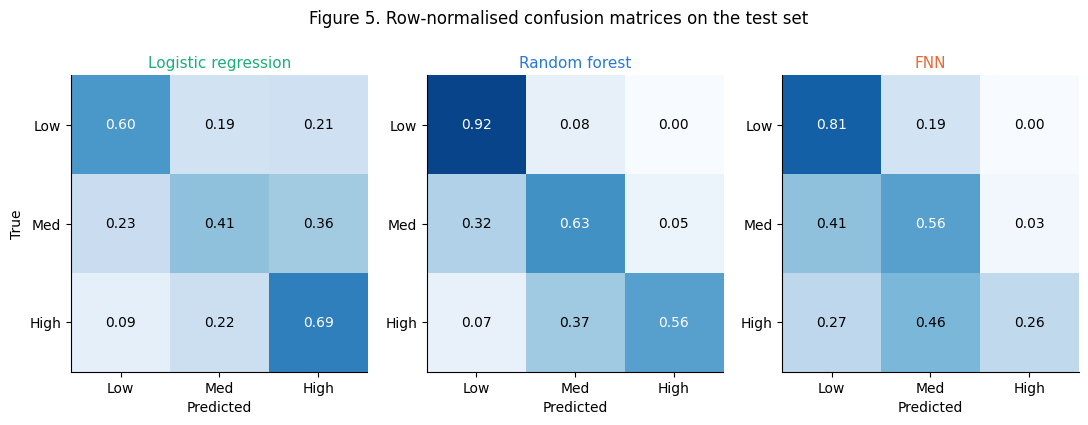

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, name in zip(axes, ['Logistic regression', 'Random forest', 'FNN']):
    cm = confusion_matrix(y_test, final[name]['pred'], labels=CLASSES, normalize='true')
    im = ax.imshow(cm, vmin=0, vmax=1, cmap='Blues')
    ax.set_title(name, color=MODEL_COLORS[name])
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xticklabels(['Low', 'Med', 'High'])
    ax.set_yticklabels(['Low', 'Med', 'High'])
    ax.set_xlabel('Predicted')
    ax.grid(False)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f'{cm[i, j]:.2f}', ha='center', va='center',
                    color='white' if cm[i, j] > 0.5 else 'black')
axes[0].set_ylabel('True')
fig.suptitle('Figure 5. Row-normalised confusion matrices on the test set', y=1.03, fontsize=12)
save_fig(fig, 'fig5_confusion_matrices')

**Reading Figure 5.** For the forest, 92% of low runs are predicted low and 63% of medium runs are predicted medium. Its errors on the high row go mainly to the neighbouring band (37% predicted medium, 7% predicted low). The FNN pushes high runs down: only 26% are predicted high, 46% medium and 27% low, which is the source of its low high-band recall and of its larger two-band error. Logistic regression spreads its errors widely: 21% of low runs are predicted high, and 36% of medium runs are predicted high, which explains its low precision for that band.

## 10. Statistical comparison

### 10.1 Paired test on the test runs

A higher score on one test set can be luck. Each pair of models is compared with an exact McNemar test, which looks only at the runs where exactly one of the two models is correct and asks whether one model wins those disagreements more often than a fair coin would. Because three pairs are tested, p-values are corrected with the Holm method. This is a paired test on the same runs, which is why it is more sensitive than comparing two accuracies directly.

In [28]:
correct = {name: (v['pred'] == y_test) for name, v in final.items()}
pairs = [('Random forest', 'FNN'), ('Random forest', 'Logistic regression'), ('FNN', 'Logistic regression')]
rows = []
for a, b in pairs:
    only_a = int(np.sum(correct[a] & ~correct[b]))
    only_b = int(np.sum(~correct[a] & correct[b]))
    n_disagree = only_a + only_b
    p_value = 1.0 if n_disagree == 0 else binomtest(min(only_a, only_b), n_disagree, 0.5).pvalue
    rows.append({'model A': a, 'model B': b, 'only A correct': only_a, 'only B correct': only_b, 'p_value': p_value})
mcnemar = pd.DataFrame(rows)
mcnemar['p_holm'] = holm_adjust(mcnemar['p_value'].values)
mcnemar['significant at 0.05'] = mcnemar['p_holm'] < 0.05
mcnemar.round(6)

,model A,model B,only A correct,only B correct,p_value,p_holm,significant at 0.05
0,Random forest,FNN,1031,320,0.000000,0.000000,True
1,Random forest,Logistic regression,1317,500,0.000000,0.000000,True
2,FNN,Logistic regression,1018,912,0.016823,0.016823,True


**Reading the output.** Among the runs on which the forest and the FNN disagree, the forest is right on 1,031 and the FNN on 320, which is far from a fair coin (p below 1e-6 after the Holm correction). The forest also beats logistic regression (1,317 against 500). The FNN is slightly better than logistic regression on accuracy (1,018 against 912, p = 0.017 after correction), which fits the accuracy ranking but not the macro F1 ranking. The test above compares correct and incorrect predictions only, so it does not see which classes are missed.

### 10.2 Bootstrap confidence intervals

The test set is a finite sample, so each macro F1 has uncertainty. Test runs are resampled with replacement many times, the same resampled runs being used for every model so the comparison stays paired. The 95% interval is the middle 95% of the resampled scores. The last column is the interval for the difference between the random forest and the FNN, which answers directly whether the gap could be zero.

In [29]:
rng = np.random.default_rng(SEED)
n_test = len(y_test)
boot = {name: [] for name in final}
for _ in range(N_BOOTSTRAP):
    idx = rng.integers(0, n_test, n_test)
    for name, v in final.items():
        boot[name].append(f1_score(y_test[idx], v['pred'][idx], average='macro'))
boot = {name: np.array(values) for name, values in boot.items()}

ci = pd.DataFrame({
    name: {'macro_f1': f1_score(y_test, final[name]['pred'], average='macro'),
           'ci_low': np.percentile(values, 2.5), 'ci_high': np.percentile(values, 97.5)}
    for name, values in boot.items()
}).T
difference = boot['Random forest'] - boot['FNN']
print('Random forest minus FNN macro F1: mean', round(difference.mean(), 4),
      '| 95% interval', round(np.percentile(difference, 2.5), 4), 'to', round(np.percentile(difference, 97.5), 4))
ci.round(4)

Random forest minus FNN macro F1: mean 0.1701 | 95% interval 0.155 to 0.1852


,macro_f1,ci_low,ci_high
Logistic regression,0.5529,0.5384,0.5658
Random forest,0.7090,0.6966,0.7214
FNN,0.5394,0.5249,0.5535


**Reading the output.** The 95% intervals of the forest (0.697 to 0.721) and of the FNN (0.525 to 0.554) are far apart, and the interval for the difference (0.155 to 0.185) excludes zero by a wide margin. The intervals of logistic regression (0.538 to 0.566) and of the FNN overlap, so those two are not clearly separated on macro F1.

### 10.3 Comparison figure

Figure 6 plots test macro F1 with its 95% bootstrap interval for all models, with the two naive baselines for reference. Non-overlapping intervals are a strong sign of a real difference; overlapping intervals call for the paired test above to decide.

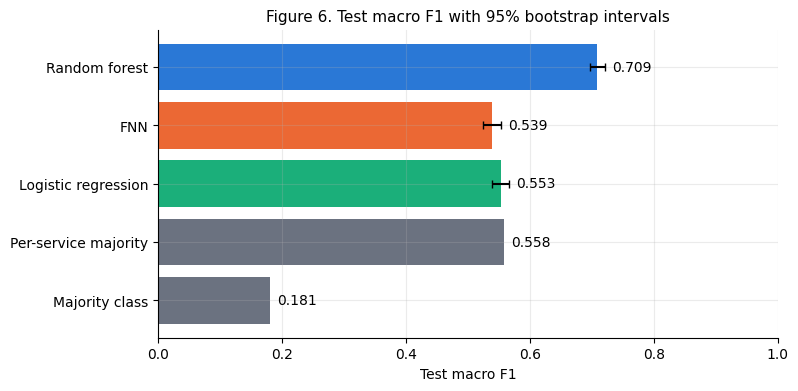

In [30]:
labels = ['Majority class', 'Per-service majority', 'Logistic regression', 'FNN', 'Random forest']
values = [test_scores.loc[l, 'macro_f1'] for l in labels]
colours = [GREY, GREY, GREEN, ORANGE, BLUE]
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(labels, values, color=colours)
for label, bar in zip(labels, bars):
    if label in ci.index:
        low, high = ci.loc[label, 'ci_low'], ci.loc[label, 'ci_high']
        ax.errorbar(bar.get_width(), bar.get_y() + bar.get_height() / 2,
                    xerr=[[bar.get_width() - low], [high - bar.get_width()]], color='black', capsize=3)
    label_x = ci.loc[label, 'ci_high'] if label in ci.index else bar.get_width()
    ax.text(label_x + 0.012, bar.get_y() + bar.get_height() / 2, f'{bar.get_width():.3f}', va='center')
ax.set_xlabel('Test macro F1')
ax.set_xlim(0, 1)
ax.set_title('Figure 6. Test macro F1 with 95% bootstrap intervals')
save_fig(fig, 'fig6_model_comparison')

**Reading Figure 6.** Only the random forest is clearly above the per-service baseline. The FNN and logistic regression are at or below it, so for them the extra modelling effort added nothing over remembering each service's usual load.

## 11. Stability and cost

### 11.1 Repeat the final fit with different seeds

A single fit can be lucky. The random forest and the FNN are each refitted with several different random seeds, using their chosen configurations, and scored on the test set each time. The spread across seeds measures how dependable the result is. Logistic regression is deterministic and is not repeated. Fit time and prediction time per 1000 runs are recorded in the same loop, so quality and cost come from the same runs.

In [31]:
stability_path = os.path.join(RES_DIR, f'stability_seeds{N_STABILITY_SEEDS}_n{N_TUNING_ITER}.csv')
if os.path.exists(stability_path):
    stability = pd.read_csv(stability_path)
    print('Loaded cached stability table')
else:
    rows = []
    for seed in range(N_STABILITY_SEEDS):
        start = time.time()
        model = make_forest(best_rf, seed=seed).fit(X_train, y_train)
        fit_s = time.time() - start
        start = time.time()
        pred = model.predict(X_test)
        predict_s = time.time() - start
        rows.append({'model': 'Random forest', 'seed': seed, 'test_macro_f1': f1_score(y_test, pred, average='macro'),
                     'test_accuracy': accuracy_score(y_test, pred), 'fit_s': fit_s,
                     'predict_s_per_1000': predict_s / len(y_test) * 1000})
        start = time.time()
        model, _ = fit_fnn(best_fnn, X_train, y_train, X_val, y_val, seed=seed)
        fit_s = time.time() - start
        start = time.time()
        pred = fnn_predict(model, X_test)
        predict_s = time.time() - start
        rows.append({'model': 'FNN', 'seed': seed, 'test_macro_f1': f1_score(y_test, pred, average='macro'),
                     'test_accuracy': accuracy_score(y_test, pred), 'fit_s': fit_s,
                     'predict_s_per_1000': predict_s / len(y_test) * 1000})
        print('seed', seed, 'done')
    stability = pd.DataFrame(rows)
    stability.to_csv(stability_path, index=False)

stability_summary = stability.groupby('model').agg(
    macro_f1_mean=('test_macro_f1', 'mean'), macro_f1_sd=('test_macro_f1', 'std'),
    accuracy_mean=('test_accuracy', 'mean'), fit_s_mean=('fit_s', 'mean'),
    predict_s_per_1000_mean=('predict_s_per_1000', 'mean'))
stability_summary.round(4)

Loaded cached stability table


,macro_f1_mean,macro_f1_sd,accuracy_mean,fit_s_mean,predict_s_per_1000_mean
model,,,,,
FNN,0.5558,0.0383,0.5849,24.2463,0.1141
Random forest,0.7102,0.0032,0.7200,3.0517,0.0188


**Reading the output.** Across five seeds the forest's test macro F1 varies by 0.003 (mean 0.710), while the FNN's varies by 0.038 (mean 0.556). A single FNN fit can differ by several points from another, so any one FNN number should be read with that spread in mind. The forest is also faster to train (about 3 s against 24 s) and to predict (0.019 s against 0.114 s per 1,000 runs).

### 11.2 Model size

Size matters for deployment. The random forest is saved with `joblib` and the FNN in the native Keras format, and the file sizes are compared. The FNN parameter count is shown as well. The saved models are also written to Drive.

In [32]:
rf_path = os.path.join(RES_DIR, 'random_forest_occupancy.joblib')
fnn_path = os.path.join(RES_DIR, 'fnn_occupancy.keras')
lr_path = os.path.join(RES_DIR, 'logreg_occupancy.joblib')
joblib.dump(forest_model, rf_path)
fnn_model.save(fnn_path)
joblib.dump(logreg_model, lr_path)

sizes = pd.DataFrame({
    'size_MB': {
        'Random forest': os.path.getsize(rf_path) / 1e6,
        'FNN': os.path.getsize(fnn_path) / 1e6,
        'Logistic regression': os.path.getsize(lr_path) / 1e6,
    }
})
print('FNN parameters:', fnn_model.count_params())
sizes.round(3)

FNN parameters: 140803


,size_MB
Random forest,28.866
FNN,1.727
Logistic regression,0.002


**Reading the output.** The forest takes 28.9 MB on disk against 1.7 MB for the FNN (140,803 parameters) and a few kilobytes for logistic regression. Size is the one cost on which the FNN wins, but 29 MB is small in absolute terms and does not limit deployment.

### 11.3 Quality against cost

Figure 7 puts quality (mean test macro F1 over seeds, with one standard deviation) against training time on a log scale. The best model for deployment is not always the one at the very top: a model that is almost as good but far cheaper, or far more stable, can be the better recommendation.

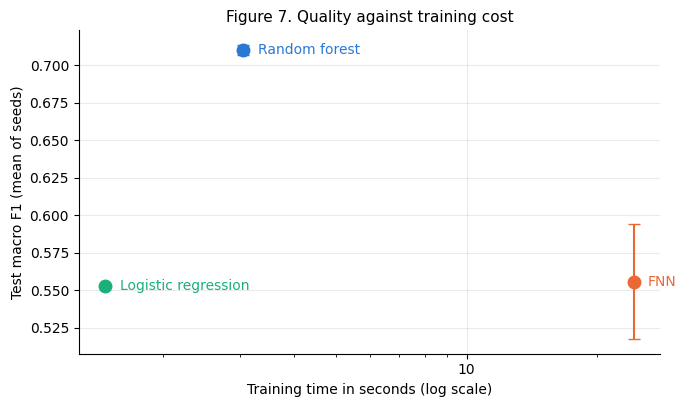

In [33]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for name in ['Random forest', 'FNN']:
    row = stability_summary.loc[name]
    ax.errorbar(row['fit_s_mean'], row['macro_f1_mean'], yerr=row['macro_f1_sd'],
                fmt='o', color=MODEL_COLORS[name], capsize=4, markersize=9)
    ax.text(row['fit_s_mean'] * 1.08, row['macro_f1_mean'], name, color=MODEL_COLORS[name], va='center')
lr_row = test_scores.loc['Logistic regression']
ax.plot(final['Logistic regression']['fit_s'], lr_row['macro_f1'], 'o', color=GREEN, markersize=9)
ax.text(final['Logistic regression']['fit_s'] * 1.08, lr_row['macro_f1'], 'Logistic regression', color=GREEN, va='center')
ax.set_xscale('log')
ax.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda v, _: f'{v:g}'))
ax.xaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())
ax.set_xlabel('Training time in seconds (log scale)')
ax.set_ylabel('Test macro F1 (mean of seeds)')
ax.set_title('Figure 7. Quality against training cost')
save_fig(fig, 'fig7_quality_vs_cost')

**Reading Figure 7.** The forest is both the best and one of the cheapest to train, so there is no trade-off between quality and cost here. The FNN costs about eight times more training time for lower quality and far more variation between seeds.

## 12. What drives the predictions

### 12.1 Permutation importance of single features

For the tuned random forest, each feature is shuffled in turn on the validation set and the drop in macro F1 is recorded. A large drop means the model relies on that feature. Permutation importance is computed on the raw feature table through a full pipeline, so one-hot columns of the same original feature are shuffled together. The validation set is used, not the test set, because this is analysis and no decision is based on the test set.

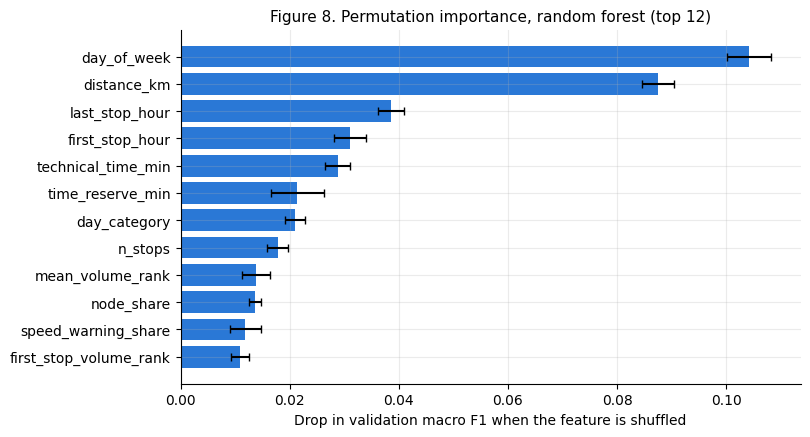

,feature,drop_in_macro_f1,sd
18,day_of_week,0.1042,0.0040
5,distance_km,0.0875,0.0029
3,last_stop_hour,0.0385,0.0024
2,first_stop_hour,0.0311,0.0030
7,technical_time_min,0.0288,0.0023
6,time_reserve_min,0.0214,0.0049
19,day_category,0.0210,0.0019
4,n_stops,0.0178,0.0019
9,mean_volume_rank,0.0138,0.0026
12,node_share,0.0136,0.0011


In [34]:
forest_pipeline = Pipeline([('prep', make_preprocessor(NUM_COLS, CAT_COLS)),
                            ('model', make_forest(best_rf))]).fit(train[FEATURES], y_train)
importance = permutation_importance(forest_pipeline, val[FEATURES], y_val, scoring='f1_macro',
                                    n_repeats=5, random_state=SEED, n_jobs=1)
importance_table = pd.DataFrame({'feature': FEATURES, 'drop_in_macro_f1': importance.importances_mean,
                                 'sd': importance.importances_std}).sort_values('drop_in_macro_f1', ascending=False)
top = importance_table.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.barh(top['feature'], top['drop_in_macro_f1'], xerr=top['sd'], color=BLUE, capsize=3)
ax.set_xlabel('Drop in validation macro F1 when the feature is shuffled')
ax.set_title('Figure 8. Permutation importance, random forest (top 12)')
save_fig(fig, 'fig8_permutation_importance')
importance_table.head(12).round(4)

**Reading the output.** Day of week is the most important feature (drop of 0.104 in macro F1 when shuffled), followed by trip distance (0.088), the hour of the last stop (0.039), the hour of the first stop (0.031) and the technical running time (0.029). The model relies on when a train runs and how long its route is, which together act as a fingerprint of the service, plus the weekday pattern of demand.

### 12.2 Ablation by feature group

Importance of single features can understate the role of a whole kind of information, because correlated features share credit. This cell refits the random forest with one group removed at a time ("leave one group out") and with only one group kept ("only this group"), and reports validation macro F1 each time, using the same chosen configuration. It shows which kinds of information the model really needs. A large drop when the timetable group is removed would suggest the model largely recognises individual services by their timetable fingerprint.

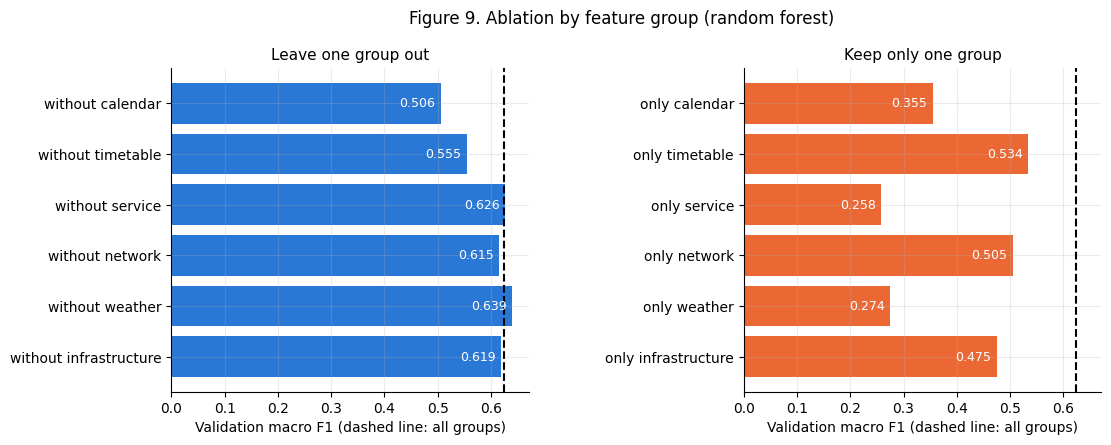

,setting,val_macro_f1,change_vs_all
0,all groups,0.6245,0.0000
1,without calendar,0.5056,-0.1189
2,without timetable,0.5547,-0.0698
3,without service,0.6257,0.0012
4,without network,0.6147,-0.0098
5,without weather,0.6393,0.0148
6,without infrastructure,0.6192,-0.0053
7,only calendar,0.3547,-0.2698
8,only timetable,0.5336,-0.0909
9,only service,0.2582,-0.3663


In [35]:
def forest_val_f1(num_cols, cat_cols):
    cols = num_cols + cat_cols
    pipe = Pipeline([('prep', make_preprocessor(num_cols, cat_cols)),
                     ('model', make_forest(best_rf))]).fit(train[cols], y_train)
    return f1_score(y_val, pipe.predict(val[cols]), average='macro')


full_f1 = forest_val_f1(NUM_COLS, CAT_COLS)
rows = [{'setting': 'all groups', 'val_macro_f1': full_f1}]
for group in GROUPS:
    rest_num = [c for g, spec in GROUPS.items() if g != group for c in spec['num']]
    rest_cat = [c for g, spec in GROUPS.items() if g != group for c in spec['cat']]
    rows.append({'setting': 'without ' + group, 'val_macro_f1': forest_val_f1(rest_num, rest_cat)})
for group, spec in GROUPS.items():
    rows.append({'setting': 'only ' + group, 'val_macro_f1': forest_val_f1(spec['num'], spec['cat'])})
ablation = pd.DataFrame(rows)
ablation['change_vs_all'] = ablation['val_macro_f1'] - full_f1
ablation.to_csv(os.path.join(RES_DIR, f'ablation_seed{SEED}.csv'), index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharex=True)
fig.subplots_adjust(wspace=0.6)
drop = ablation[ablation['setting'].str.startswith('without')].iloc[::-1]
keep = ablation[ablation['setting'].str.startswith('only')].iloc[::-1]
axes[0].barh(drop['setting'], drop['val_macro_f1'], color=BLUE)
axes[1].barh(keep['setting'], keep['val_macro_f1'], color=ORANGE)
for ax, frame, title in [(axes[0], drop, 'Leave one group out'), (axes[1], keep, 'Keep only one group')]:
    ax.axvline(full_f1, color='black', linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('Validation macro F1 (dashed line: all groups)')
    for i, v in enumerate(frame['val_macro_f1']):
        ax.text(v - 0.01, i, f'{v:.3f}', va='center', ha='right', color='white', fontsize=9)
fig.suptitle('Figure 9. Ablation by feature group (random forest)', y=1.02, fontsize=12)
save_fig(fig, 'fig9_ablation')
ablation.round(4)

**Reading the output.** Removing the calendar group costs the most (validation macro F1 falls by 0.119), followed by the timetable group (0.070). Removing the service, network or infrastructure groups changes the score by about 0.01 or less, because other groups carry the same information. Removing the weather group raises the score by 0.015, so the weather features add noise rather than signal in this three-month spring window. On their own, the timetable group (0.534) and the network group (0.505) are the strongest, while weather alone is nearly useless (0.274). The signal is in the schedule and calendar, not in the conditions on the day.

## 13. Where the models fail

### 13.1 Error by train category and by day of week

An average score can hide pockets where a model is much worse. This cell splits the test accuracy of the random forest and the FNN by train category and by day of week. Large gaps point to subgroups where the model should not be trusted without more data, which feeds the limitations discussion.

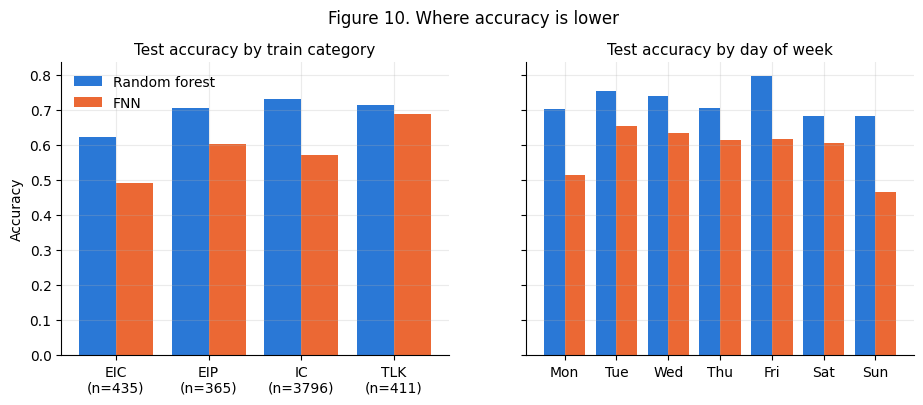

,Random forest,FNN,runs
category,,,
EIC,0.623,0.492,435
EIP,0.707,0.603,365
IC,0.731,0.571,3796
TLK,0.715,0.689,411


In [36]:
analysis = test[['category', 'day_of_week']].copy()
analysis['Random forest'] = final['Random forest']['pred'] == y_test
analysis['FNN'] = final['FNN']['pred'] == y_test
by_category = analysis.groupby('category')[['Random forest', 'FNN']].mean()
by_category['runs'] = analysis.groupby('category').size()
by_day = analysis.groupby(analysis['day_of_week'].astype(int))[['Random forest', 'FNN']].mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
x = np.arange(len(by_category))
axes[0].bar(x - 0.2, by_category['Random forest'], 0.4, color=BLUE, label='Random forest')
axes[0].bar(x + 0.2, by_category['FNN'], 0.4, color=ORANGE, label='FNN')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'{c}\n(n={n})' for c, n in zip(by_category.index, by_category['runs'])])
axes[0].set_title('Test accuracy by train category')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
x = np.arange(len(by_day))
axes[1].bar(x - 0.2, by_day['Random forest'], 0.4, color=BLUE)
axes[1].bar(x + 0.2, by_day['FNN'], 0.4, color=ORANGE)
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'][:len(by_day)])
axes[1].set_title('Test accuracy by day of week')
fig.suptitle('Figure 10. Where accuracy is lower', y=1.02, fontsize=12)
save_fig(fig, 'fig10_error_by_subgroup')
by_category.round(3)

**Reading Figure 10.** The forest is more accurate than the FNN in every train category. It is best on IC (0.731, the large majority of runs) and weakest on EIC (0.623, 435 runs), where there are fewer examples. The FNN is weakest on EIC (0.492) and IC (0.571) and comes closest to the forest on TLK (0.689 against 0.715). Small categories give noisier estimates, so differences between them should be read with caution.

## 14. Summary table

### 14.1 One table for the report

This cell collects the headline numbers into one table: test accuracy and macro F1, ordinal metrics, the seed stability of the two tuned models, training and prediction time, and model size. The table is saved to Drive and is the source of the numbers quoted in the report, so the report and notebook cannot drift apart. The recommendation in the report rests on this table together with the significance tests above, not on a single metric.

In [37]:
summary = test_scores[['accuracy', 'macro_f1', 'balanced_accuracy', 'weighted_kappa', 'two_band_error', 'log_loss']].copy()
summary['macro_f1_sd_over_seeds'] = np.nan
summary['fit_seconds'] = np.nan
summary['predict_seconds_per_1000_runs'] = np.nan
summary['model_size_MB'] = np.nan
for name in ['Random forest', 'FNN']:
    summary.loc[name, 'macro_f1_sd_over_seeds'] = stability_summary.loc[name, 'macro_f1_sd']
    summary.loc[name, 'fit_seconds'] = stability_summary.loc[name, 'fit_s_mean']
    summary.loc[name, 'predict_seconds_per_1000_runs'] = stability_summary.loc[name, 'predict_s_per_1000_mean']
    summary.loc[name, 'model_size_MB'] = sizes.loc[name, 'size_MB']
summary.loc['Logistic regression', 'fit_seconds'] = final['Logistic regression']['fit_s']
summary.loc['Logistic regression', 'predict_seconds_per_1000_runs'] = final['Logistic regression']['predict_s'] / len(y_test) * 1000
summary.loc['Logistic regression', 'model_size_MB'] = sizes.loc['Logistic regression', 'size_MB']
summary.to_csv(os.path.join(RES_DIR, f'final_summary_seed{SEED}.csv'))
summary.round(4)

,accuracy,macro_f1,balanced_accuracy,weighted_kappa,two_band_error,log_loss,macro_f1_sd_over_seeds,fit_seconds,predict_seconds_per_1000_runs,model_size_MB
model,,,,,,,,,,
Majority class,0.3719,0.1807,0.3333,0.0000,0.2624,NaN,NaN,NaN,NaN,NaN
Per-service majority,0.5998,0.5580,0.5691,0.5269,0.0529,NaN,NaN,NaN,NaN,NaN
Logistic regression,0.5552,0.5529,0.5681,0.4526,0.1017,0.9240,NaN,1.4687,0.0008,0.0017
Random forest,0.7184,0.7090,0.7024,0.7207,0.0188,0.6673,0.0032,3.0517,0.0188,28.8658
FNN,0.5764,0.5394,0.5457,0.4386,0.0725,0.8865,0.0383,24.2463,0.1141,1.7270


### 14.2 Files written to Drive

A last check lists everything the notebook saved, so the figures and result tables used in the report can be found and re-used.

In [38]:
for folder in [FIG_DIR, RES_DIR]:
    print(folder)
    for name in sorted(os.listdir(folder)):
        print('   ', name, round(os.path.getsize(os.path.join(folder, name)) / 1e3, 1), 'KB')

/content/gdrive/MyDrive/IntroToAI/AT1_III/figures
    fig10_error_by_subgroup.png 71.1 KB
    fig1_class_balance.png 120.8 KB
    fig2_time_patterns.png 104.9 KB
    fig3_class_shift.png 65.8 KB
    fig4_tuning_landscape.png 91.9 KB
    fig5_confusion_matrices.png 94.2 KB
    fig6_model_comparison.png 64.2 KB
    fig7_quality_vs_cost.png 68.0 KB
    fig8_permutation_importance.png 96.2 KB
    fig9_ablation.png 127.9 KB
/content/gdrive/MyDrive/IntroToAI/AT1_III/results
    ablation_seed42.csv 0.7 KB
    final_summary_seed42.csv 1.0 KB
    fnn_occupancy.keras 1727.0 KB
    logreg_occupancy.joblib 1.7 KB
    random_forest_occupancy.joblib 28865.8 KB
    stability_seeds5_n20.csv 0.9 KB
    test_predictions_seed42.csv 93.3 KB
    test_scores_seed42.csv 0.7 KB
    tuning_fnn_n20_seed42.csv 4.0 KB
    tuning_forest_n20_seed42.csv 3.7 KB
    tuning_logreg_n8_seed42.csv 0.7 KB


## 15. Findings

### 15.1 What the experiments show

1. **Random forest is the best of the three techniques on this problem.** On the 5,007 held-out test runs it reaches a macro F1 of 0.709, against 0.553 for logistic regression and 0.539 for the FNN. The difference to the FNN is large (0.155 to 0.185 in a 95% interval) and significant in a paired test.
2. **The forest is also the most dependable and cheapest.** Its seed-to-seed variation is 0.003 against 0.038 for the FNN, it trains about eight times faster and predicts about six times faster. Its only disadvantage is size (28.9 MB against 1.7 MB).
3. **The baselines matter.** The per-service baseline (0.558) is hard to beat. Logistic regression and the FNN do not beat it on macro F1, so only the forest shows that planning-time information adds value beyond remembering each service's usual load.
4. **Calendar and timetable carry the signal.** Day of week and route length are the strongest features, and weather adds nothing in this window.
5. **The high band is the weak spot.** Even the forest finds only 56% of the crowded trains, partly because high occupancy is more common in the test period (26.2%) than in training (19.6%).

### 15.2 Limits of the evidence

The data covers one operator, one spring season of about 11 weeks, and one occupancy estimate that the operator itself provides. Weather values are treated as if they were forecasts. The models were chosen on a validation period that had a different class mix from the test period, so the test score includes some sensitivity to that shift. Results should not be extended to winter, holidays or other operators without new data.

### 15.3 Recommendation

For this problem the random forest is recommended: it is the most accurate, the most stable across seeds, the cheapest to train and to run, and the only model that clearly improves on the per-service baseline. The FNN is not recommended here. Before relying on any model for crowding warnings, the high-occupancy recall should be improved, for example by class weighting or a decision threshold tuned for that band, and the model should be refitted on a longer period that includes other seasons.